In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import download_prices
from src.returns import compute_simple_returns

In [2]:
from src.data import download_prices

prices = download_prices(
    tickers=["SPY", "QQQ", "IWM"],
    start="2015-01-01",
    end="2026-01-01",
)

print(prices.shape)
print(prices.columns)

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
(2766, 3)
Index(['SPY', 'QQQ', 'IWM'], dtype='object')


In [5]:
prices.head()

,SPY,QQQ,IWM
Date,,,
2015-01-02,169.687866,94.561134,102.543121
2015-01-05,166.623337,93.174057,101.172203
2015-01-06,165.053925,91.924744,99.421921
2015-01-07,167.110687,93.109741,100.646263
2015-01-08,170.076004,94.891846,102.353447


In [7]:
print(prices["SPY"].head())

Date
2015-01-02    169.687866
2015-01-05    166.623337
2015-01-06    165.053925
2015-01-07    167.110687
2015-01-08    170.076004
Name: SPY, dtype: float64


In [9]:
returns = compute_simple_returns(prices)

print(prices.shape)
print(returns.shape)
print(returns.head())
print(returns.isna().sum())

(2766, 3)
(2765, 3)
                 SPY       QQQ       IWM
Date                                    
2015-01-05 -0.018060 -0.014669 -0.013369
2015-01-06 -0.009419 -0.013408 -0.017300
2015-01-07  0.012461  0.012891  0.012315
2015-01-08  0.017745  0.019140  0.016962
2015-01-09 -0.008014 -0.006583 -0.009603
SPY    0
QQQ    0
IWM    0
dtype: int64


In [11]:
normalized_prices = prices / prices.iloc[0]

In [13]:
print(normalized_prices.head())

                 SPY       QQQ       IWM
Date                                    
2015-01-02  1.000000  1.000000  1.000000
2015-01-05  0.981940  0.985331  0.986631
2015-01-06  0.972691  0.972120  0.969562
2015-01-07  0.984812  0.984651  0.981502
2015-01-08  1.002287  1.003497  0.998150


In [15]:
import matplotlib.pyplot as plt

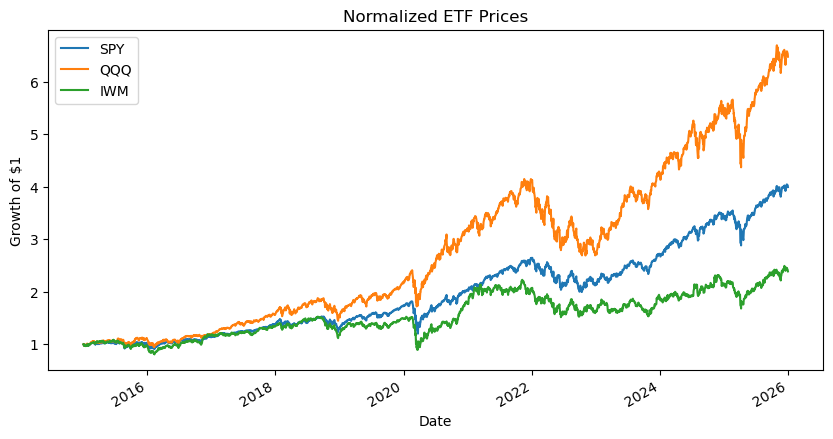

In [19]:
ax = normalized_prices.plot(figsize=(10,5))
ax.set_title("Normalized ETF Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

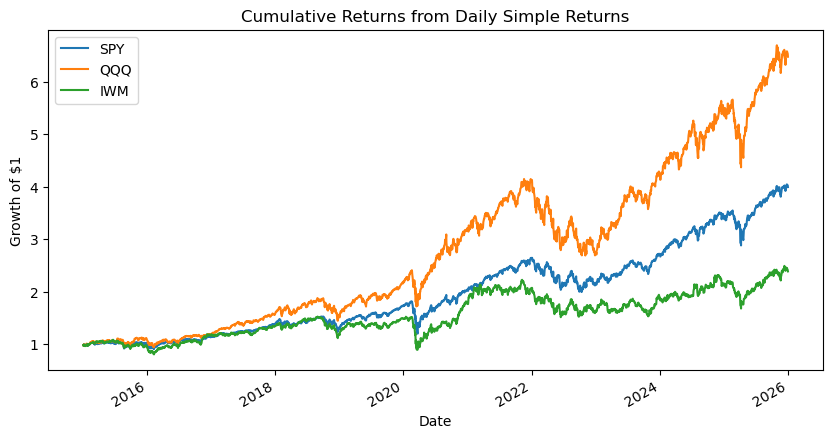

In [21]:
cumulative_returns = (1 + returns).cumprod()

ax = cumulative_returns.plot(figsize=(10, 5))

ax.set_title("Cumulative Returns from Daily Simple Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [23]:
print(normalized_prices.head())
print(cumulative_returns.head())
print(cumulative_returns.tail())

                 SPY       QQQ       IWM
Date                                    
2015-01-02  1.000000  1.000000  1.000000
2015-01-05  0.981940  0.985331  0.986631
2015-01-06  0.972691  0.972120  0.969562
2015-01-07  0.984812  0.984651  0.981502
2015-01-08  1.002287  1.003497  0.998150
                 SPY       QQQ       IWM
Date                                    
2015-01-05  0.981940  0.985331  0.986631
2015-01-06  0.972691  0.972120  0.969562
2015-01-07  0.984812  0.984651  0.981502
2015-01-08  1.002287  1.003497  0.998150
2015-01-09  0.994255  0.996892  0.988565
                 SPY       QQQ       IWM
Date                                    
2025-12-24  4.047022  6.582622  2.454214
2025-12-26  4.046612  6.582201  2.441686
2025-12-29  4.032191  6.550338  2.426731
2025-12-30  4.027267  6.535145  2.408764
2025-12-31  3.997429  6.481128  2.390603
